<a href="https://colab.research.google.com/github/TrishaBalamurugan/AU---Projects/blob/main/TPB_Global_Air_Pollution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

pfrom google.colab import drive
drive.mount('/content/drive')

SyntaxError: invalid syntax (ipython-input-1-2939733306.py, line 1)

#AQI Values in the Americas

This notebook will display the AQI values for various cities in the Americas. There will be three graphs, one for each region: North, South, and Central. Each graph will be a scatterplot, with each dot representing a city. The x-axis will represent increasing population, right to left. The y-axis will represent AQI values.

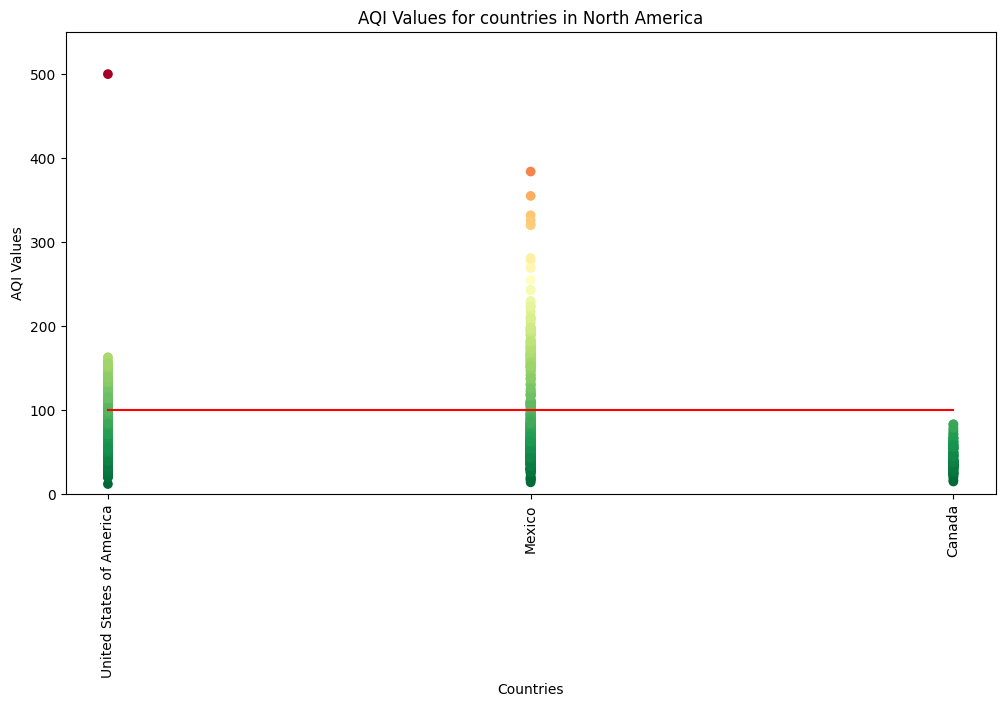

In [ ]:
#Imports External Librarys

#Enrique did this
from IPython.display import set_matplotlib_formats
import csv
import pandas as pd
import matplotlib.pyplot as plt
import statistics
import numpy as np

AmericaCSV = '/content/drive/MyDrive/Air_Pollution/Americas Air Pollition Dataset.csv'
NACSV = '/content/drive/MyDrive/Air_Pollution/North America Air Pollition Dataset.csv'
CACSV = '/content/drive/MyDrive/Air_Pollution/South America Air Pollition Dataset.csv'
SACSV = '/content/drive/MyDrive/Air_Pollution/Central America Air Pollition Dataset.csv'

def f(x):
  return 100

def newCSV(directory, continent):
    NewDataSet = df[df['Country'].isin(continent)]
    NewDataSet.to_csv(directory)
    NewDataSet = pd.read_csv(directory)
    return NewDataSet

def median(dataset, countrys, list):
  dictionary = {}
  for i in list:
    temp= []
    for j in range(len(countrys)):
        if countrys[j] == i:
          temp.append(dataset[j])
    med = statistics.median(temp)
    dictionary[i] = med
  return dictionary

def plotting(Continent, actualList):
  plt.figure(figsize=(12, 6))
  plt.ylim(0,550)
  normalized_AQI = np.array(AQIValue) / max(AQIValue)
  cmap = plt.get_cmap('RdYlGn_r')
  plt.scatter(Country, AQIValue,c=normalized_AQI, cmap=cmap).set_facecolor("black")
  x = [0, len(actualList) - 1]
  y = [100, 100]
  plt.plot(x, y, color = 'red')
  plt.xticks(rotation=90)
  plt.title(f"AQI Values for countries in {Continent}")
  plt.xlabel("Countries")
  plt.ylabel("AQI Values")

  plt.show()

def listing(continentDataSet):
  City = continentDataSet['City']
  Country = continentDataSet['Country']
  AQIValue = continentDataSet['AQI Value']
  return City, Country, AQIValue

#prit Did this
#Uses Pandas to read the dataset csv file
df = pd.read_csv('/content/drive/MyDrive/Air_Pollution/Global Air Pollition Dataset.csv')


#Lists for contenents being used in data
NorthAmerica = ['United States of America', 'Canada', 'Mexico']
CentralAmerica = ['Aruba', 'Barbados', 'Cuba', 'Dominican Republic', 'Haiti', 'Jamaica', 'Saint Lucia', 'Saint Kitts and Nevis', 'Trinidad and Tobago', 'Belize', 'Costa Rica', 'El Salvador', 'Guatemala', 'Honduras', 'Nicaragua', 'Panama']
SouthAmerica = ['Argentina', 'Bolivia (Plurinational State of)', 'Brazil', 'Chile', 'Colombia', 'Ecuador', 'Guyana', 'Paraguay', 'Peru', 'Suriname', 'Uruguay', 'Venezuela (Bolivarian Republic of)']
Americas = NorthAmerica + SouthAmerica + CentralAmerica

#adds only wanted data to a new csv file
NewDataSet = newCSV(AmericaCSV, Americas)
NADataSet = newCSV(NACSV, NorthAmerica)
CADataSet = newCSV(CACSV, CentralAmerica)
SADataSet = newCSV(SACSV, SouthAmerica)


#Jun Kim   Did this
#makes a list for Countrys, Cities, and Aqi Values
City, Country, AQIValue = listing(NADataSet)
NADictionary = median(AQIValue, Country, NorthAmerica)
plotting('North America', NorthAmerica)
print()
box1 = []
box2 = []
box3 = []


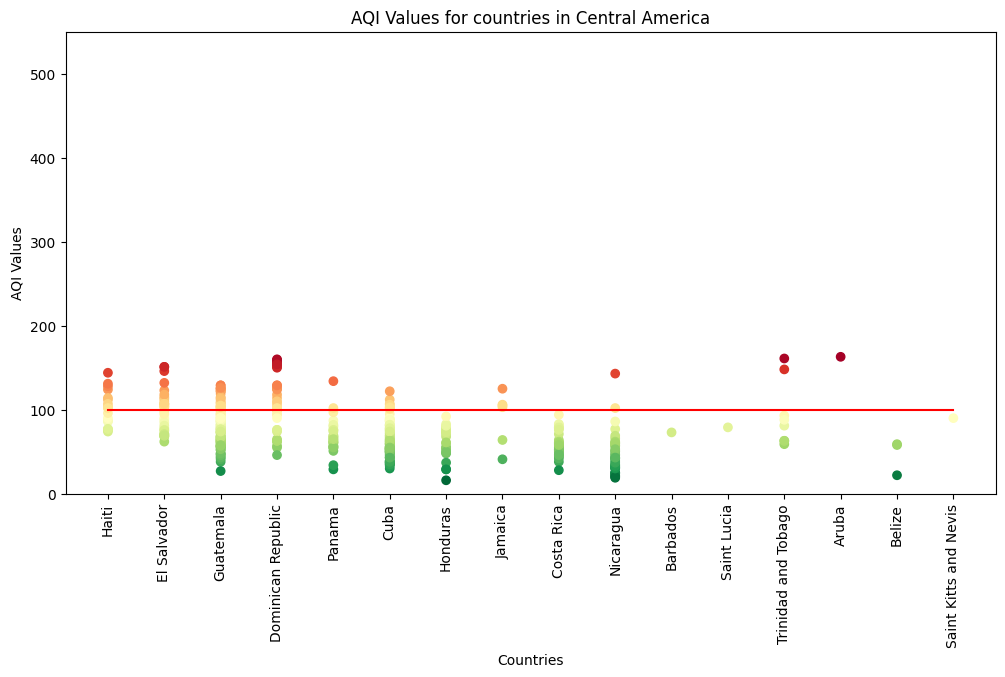

In [ ]:
#Trisha Balamurugan   Did this Scatter Plot graph representing the AQI Values for countries in Central America
City, Country, AQIValue = listing(CADataSet)
CADictionary = median(AQIValue, Country, CentralAmerica)
plotting('Central America', CentralAmerica)

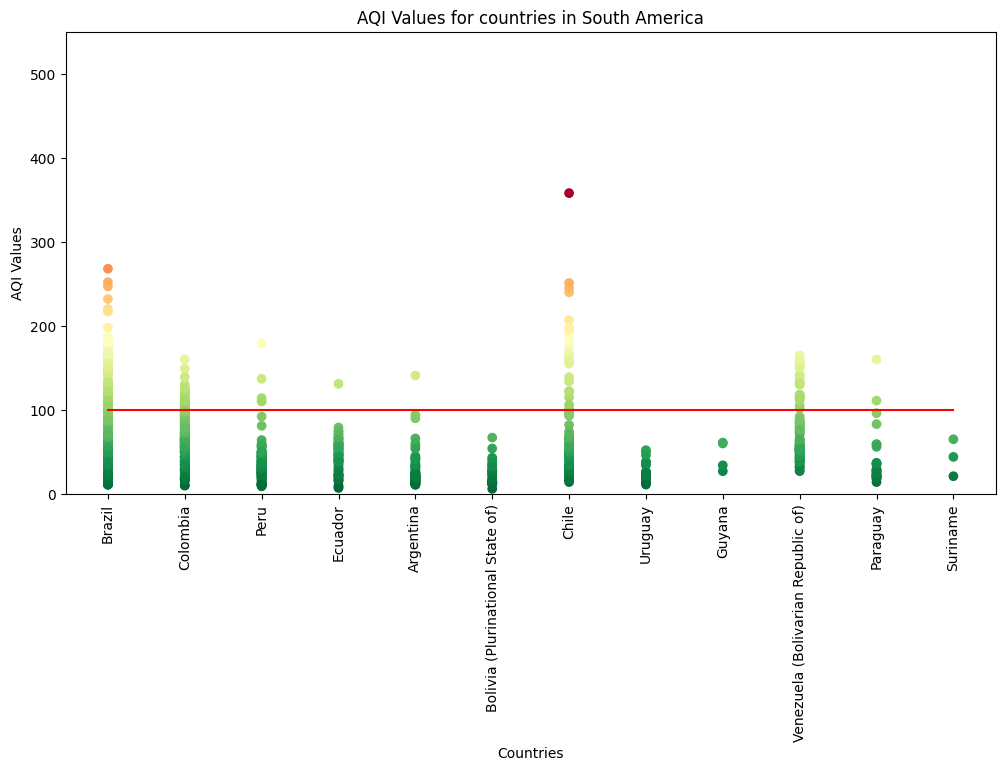

In [ ]:
#Simone   Did this
City, Country, AQIValue = listing(SADataSet)
SADictionary = median(AQIValue, Country, SouthAmerica)
plotting('South America', SouthAmerica)

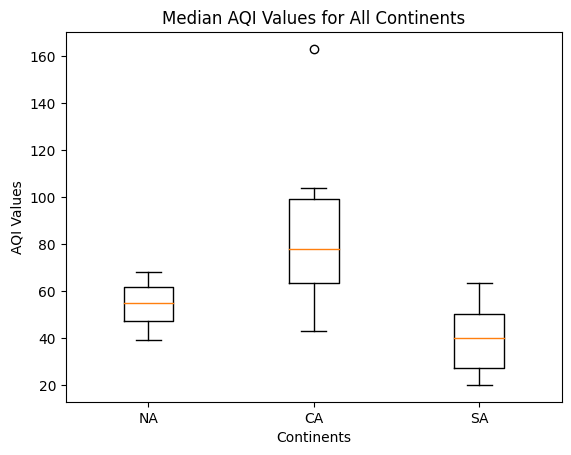

In [ ]:
NA = []
SA = []
CA = []
NA.extend(NADictionary.values())
SA.extend(SADictionary.values())
CA.extend(CADictionary.values())
cool = [NA, CA, SA]
plt.boxplot(cool)
plt.xticks([1, 2, 3], ['NA', 'CA', 'SA'])
plt.ylabel("AQI Values")
plt.title("Median AQI Values for All Continents")
plt.xlabel("Continents")
plt.show()